In [2]:
import pandas as pd
import numpy as np
import holidays as hp
from xgboost import  XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.regularizers import L2
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import  TimeSeriesSplit
from tensorflow.keras.optimizers import SGD


In [3]:
df = pd.read_csv('/home/purushottam/MACHINE LEARNING/TIME SERIES/COMPTETIONS/FAVORITA COMPETITONS/favo train.csv')

In [4]:
df

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0
1,1,2013-01-01,1,BABY CARE,0.000,0
2,2,2013-01-01,1,BEAUTY,0.000,0
3,3,2013-01-01,1,BEVERAGES,0.000,0
4,4,2013-01-01,1,BOOKS,0.000,0
...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8


In [5]:
df = df.sample(n= 100000)

In [20]:
def process_data(df):
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    
    df_category = df.select_dtypes(include= 'str').columns
    df = pd.get_dummies(df, columns= df_category)
    
    q1 = df['sales'].quantile(0.25)
    q3 = df['sales'].quantile(0.75)

    iqr = q3 - q1

    upper = q3 + 1.5 * iqr

    lower = q1  - 1.5 * iqr

    df = df[(df['sales'] <= upper) & (df['sales'] >= 10)]

    return df



In [21]:
df = process_data(df)

In [22]:
us_holidays = hp.US(years = range(df['date'].dt.year.min() , df['date'].dt.year.max() + 2))

date_holidays = sorted(us_holidays.keys())

def days_to_holidays(date):

    future_holidays = [h for h in date_holidays if h >= date.date()]

    if future_holidays:
        return (future_holidays[0] - date.date()).days

    return None

    

In [23]:
def time(df):
    df['Month'] = df['date'].dt.month
    df['Year'] = df['date'].dt.year
    df['Dayofweek'] = df['date'].dt.dayofweek
    df['Dayofyear'] = df['date'].dt.dayofyear
    df['Day'] = df['date'].dt.day
    df['Quarter'] = df['date'].dt.quarter
    return df

def features_target(df):
    df['Target'] = df['sales'].shift(-1)
    df['Lag 1'] = df['sales'].shift(1)
    df['Lag 7'] = df['sales'].shift(7)
    df['Lag 30'] = df['sales'].shift(30)
    df['MA 7'] = df['sales'].shift(1).rolling(7).mean()
    df['MA 30'] = df['sales'].shift(1).rolling(30).mean()
    df['STD 7'] = df['sales'].shift(1).rolling(7).std()
    df['STD 30'] = df['sales'].shift(1).rolling(30).std()
    return df

def residuals_features_target(df):
    df['RLag 7'] = df['Residuals'].shift(7)
    df['RLag 30'] = df['Residuals'].shift(30)
    df['RMA 7'] = df['Residuals'].shift(1).rolling(7).mean()
    df['RMA 30'] = df['Residuals'].shift(1).rolling(30).mean()
    df['RSTD 7'] = df['Residuals'].shift(1).rolling(7).std()
    df['RSTD 30'] = df['Residuals'].shift(1).rolling(30).std()
    return df


In [24]:
train = df[(df['date'] >= '2013-01-01') & (df['date'] < '2016-03-01')]
val = df[(df['date'] >= '2016-03-01') & (df['date'] < '2017-01-01')]
test = df[(df['date'] >= '2017-01-01') & (df['date'] <= '2017-08-15')]

zero_std_cols = train.columns[train.std() == 0]

train = train.drop(columns= zero_std_cols)
val = val.drop(columns = zero_std_cols)
test = test.drop(columns= zero_std_cols)

In [25]:
train_l = train.copy()
val_l = val.copy()
test_l = test.copy()

In [26]:
train = features_target(train)
train = time(train)

val = features_target(val)
val = time(val)

test = features_target(test)
test = time(test)

train['Days_to_holidays'] = train['date'].apply(days_to_holidays)
val['Days_to_holidays'] = val['date'].apply(days_to_holidays)
test['Days_to_holidays'] = test['date'].apply(days_to_holidays)


train.dropna(inplace = True)
val.dropna(inplace= True)
test.dropna(inplace= True)

In [27]:
del train['date']
del val['date']
del test['date']

In [28]:
x_train = train.drop('Target', axis = 1)
y_train = train['Target']

x_val = val.drop('Target', axis = 1)
y_val = val['Target']

x_test = test.drop('Target', axis = 1)
y_test = test['Target']

In [29]:
def Time_Series_validate(x_train, y_train):
    
    tsv = TimeSeriesSplit(n_splits= 5)

    pred = np.full(len(x_train),np.nan)

    for fold,(train_idx, pred_idx) in enumerate(tsv.split(x_train)):
        x_tr = x_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]

        predi = x_train.iloc[pred_idx]

        model = XGBRegressor(n_estimators=  1500, learning_rate = 0.005, max_depth = 5)

        model.fit(x_tr, y_tr)

        pred[pred_idx] = model.predict(predi)

    return pred


In [30]:
time_train_pred = Time_Series_validate(x_train, y_train)

In [31]:
xgb = XGBRegressor(n_estimators = 1000, learning_rate = 0.005, max_depth = 7)
xgb.fit(x_train, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [32]:
pred_train = xgb.predict(x_train)
pred_val = xgb.predict(x_val)


In [33]:
mae_train = mean_absolute_error(y_train, pred_train)
print ("TRAIN ERROR:%.2f"%mae_train)
mae_val = mean_absolute_error(y_val, pred_val)
print ("VAL ERROR:%.2f"%mae_val)

TRAIN ERROR:228.09
VAL ERROR:247.87


In [34]:
train_l['Target'] = train_l['sales'].shift(-1)
val_l['Target'] = val_l['sales'].shift(-1)
test_l['Target'] = test_l['sales'].shift(-1)

In [35]:
train_l = train_l.iloc[31:]
val_l = val_l.iloc[31:]

In [38]:
train_l['Predictions'] = time_train_pred
train_l['Residuals'] = train_l['Target'] - train_l['Predictions']

val_l['Predictions'] = pred_val
val_l['Residuals'] = val_l['Target'] - val_l['Predictions']

In [39]:
print (train_l.shape)
print (time_train_pred[124:].shape)
print (val_l.shape)
print (pred_val.shape)



(28037, 38)
(27913,)
(9411, 38)
(9411,)


In [40]:
def window(x, y, window):
    x = np.array(x)
    y = np.array(y)

    x_seq = []
    y_seq = []

    for i in range(window, len(x)):
        x_seq.append(x[i - window : i])
        y_seq.append(y[i])

    return np.array(x_seq), np.array(y_seq)

def scaler(x_train, y_train):
    x_mean = x_train.mean()
    x_std = x_train.std()

    y_mean = y_train.mean()
    y_std = y_train.std()

    x_train_sc = (x_train - x_mean) / x_std

    y_train_sc = (y_train - y_mean) / y_std

    return x_train_sc, y_train_sc
                            


In [41]:
train_l = residuals_features_target(train_l)
train_l = time(train_l)

val_l = residuals_features_target(val_l)
val_l = time(val_l)

train_l.dropna(inplace= True)
val_l.dropna(inplace= True)



In [42]:
del train_l['date']
del val_l['date']

In [43]:
x_train_l = train_l.drop(['Residuals', 'Target'], axis = 1)
y_train_l = train_l['Residuals']

x_val_l = val_l.drop(['Residuals', 'Target'], axis = 1)
y_val_l = val_l['Residuals']

In [44]:
zero_std_l = x_train_l.columns[x_train_l.std() == 0]

x_train_l = x_train_l.drop(columns= zero_std_l)
x_val_l = x_val_l.drop(columns= zero_std_l)

In [45]:
x_mean = x_train_l.mean()
x_std = x_train_l.std()

x_train_sc = (x_train_l - x_mean) / x_std
x_val_sc = (x_val_l - x_mean) / x_std

y_mean = y_train_l.mean()
y_std = y_train_l.std()

y_train_sc = (y_train_l - y_mean) / y_std
y_val_sc = (y_val_l - y_mean ) / y_std



In [46]:
x_train_sc, y_train_sc = window(x_train_sc, y_train_sc, 30)
x_val_sc, y_val_sc = window(x_val_sc, y_val_sc, 30)

In [47]:
gru = Sequential()
gru.add(LSTM(128, input_shape = (x_train_sc.shape[1], x_train_sc.shape[2])))
gru.add(Dense(64, activation= 'leaky_relu'))
gru.add(Dense(32, activation= 'leaky_relu'))
gru.add(Dense(16, activation= 'leaky_relu'))
gru.add(Dense(1))

gru.compile(optimizer= SGD(learning_rate= 0.009, clipvalue= 0.001, momentum= 0.05), loss= 'mean_absolute_error')


I0000 00:00:1787479498.540797   84140 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/purushottam/TIMESERIESGPU/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [48]:
gru.fit(x_train_sc, y_train_sc, epochs = 32, batch_size= 32)

Epoch 1/32


2026-08-23 10:05:02.318195: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92400


729/729 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 0.7586
Epoch 2/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.7219
Epoch 3/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.7036
Epoch 4/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.6946
Epoch 5/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.6906
Epoch 6/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.6888
Epoch 7/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.6876
Epoch 8/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.6867
Epoch 9/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.6860
Epoch 10/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.6853
Epoch 11/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.6848
Epoch 12/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.6842
Epoch 13/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.6838
Epoch 14/32
729/729 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.6834
Epoch 15/32
729/729 ━━━━━━━━━━━━━━━━━━━━

In [49]:
predict_train = gru.predict(x_train_sc)
predict_val = gru.predict(x_val_sc)

729/729 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
293/293 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [52]:
predict_train = np.reshape(predict_train, (23299 ,))
predict_val = np.reshape(predict_val, (9350 ,))

In [53]:
predict_train = predict_train * y_std.item() + y_mean.item()
predict_val = predict_val * y_std.item() + y_mean.item()

In [63]:
y_final_train = train['Target'].iloc[4738:].to_numpy()
y_final_val = val['Target'].iloc[61:].to_numpy()

In [72]:
final_predict_train = pred_train[4738:] + predict_train
final_predict_val = pred_val[61:] + predict_val

In [74]:
mae_final_train = mean_absolute_error(y_final_train, final_predict_train)
print ("TRAIN FINAL ERROR:%.2f"%mae_final_train)
mae_final_val = mean_absolute_error(y_final_val, final_predict_val)
print ("VAL FINAL ERROR:%.2f"%mae_final_val)

TRAIN FINAL ERROR:212.75
VAL FINAL ERROR:219.51


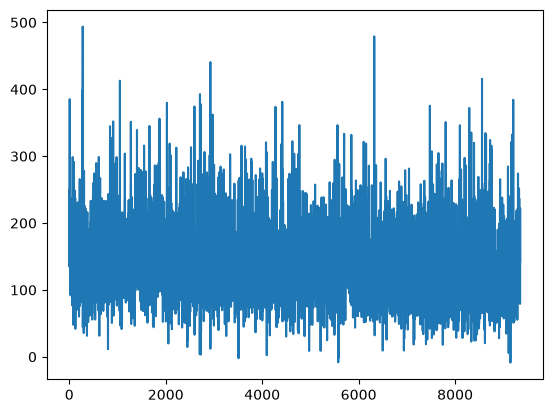

In [76]:
import matplotlib.pyplot as plt


plt.plot(final_predict_val)

In [98]:
df['Target'] = df['sales'].shift(-1)
df['Persistence'] = df['Target'].shift(1).rolling(7).mean()
df.dropna(inplace= True)
mae_per = mean_absolute_error(df['Target'], df['Persistence'])
print ("PERSISTENCE ERROR:%.2f"%mae_per)

PERSISTENCE ERROR:873.88


In [67]:
pred_val

array([238.60265, 270.96378, 249.81471, ..., 257.66315, 388.02524,
       340.74808], shape=(9411,), dtype=float32)